## Question 1a


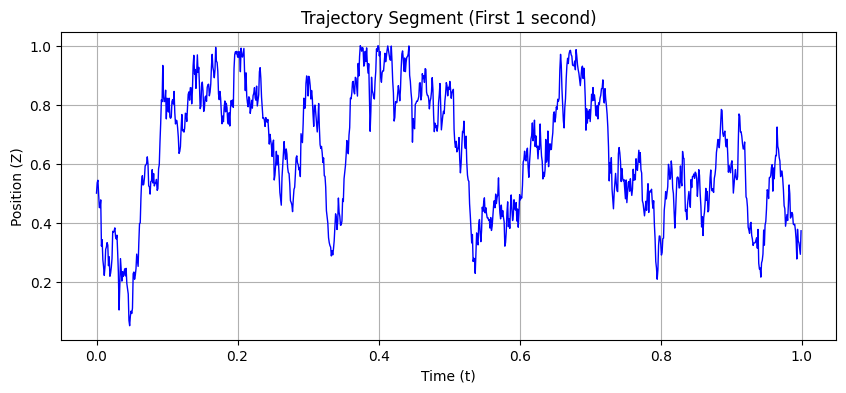

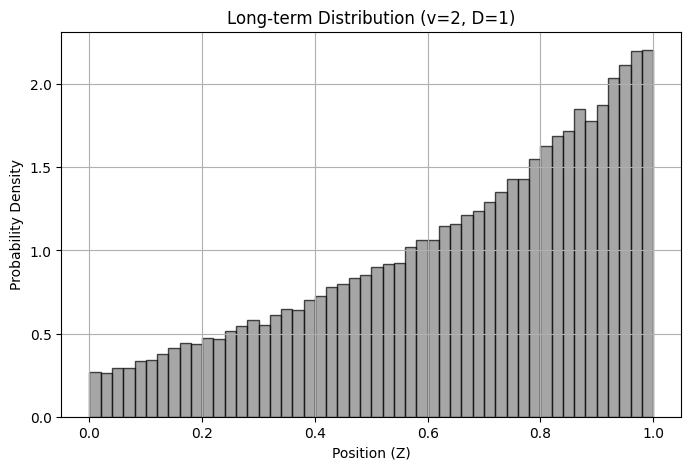

In [27]:
import numpy as np
import matplotlib.pyplot as plt

def step_vertical(Z, v, delta_t, D, H):
    X = np.random.randn(*np.shape(Z))
    Z_next = Z + v * delta_t + np.sqrt(2 * D * delta_t) * X
    
    # top reflection
    Z_next = np.where(Z_next > H, 2 * H - Z_next, Z_next)
    # bot reflection
    Z_next = np.where(Z_next < 0, -Z_next, Z_next)
    
    return Z_next

H, D, v = 1, 1, 2
T = 100
delta_t = 10**(-3)
steps = int(T / delta_t)
t = np.linspace(0, T, steps + 1)
Z = np.zeros(steps + 1)
Z[0] = H / 2

for i in range(steps):
    Z[i+1] = step_vertical(Z[i], v, delta_t, D, H)


# plot a segment of the trajectory (first 1 second or 1000 steps)
plt.figure(figsize=(10, 4))
plt.plot(t[:1000], Z[:1000], color='blue', linewidth=1)
plt.title("Trajectory Segment (First 1 second)")
plt.xlabel("Time (t)")
plt.ylabel("Position (Z)")
plt.grid(True)
plt.show()

# plot the histogram of the long-term position
plt.figure(figsize=(8, 5))
plt.hist(Z, bins=50, density=True, color='gray', edgecolor='black', alpha=0.7)
plt.title(f"Long-term Distribution (v={v}, D={D})")
plt.xlabel("Position (Z)")
plt.ylabel("Probability Density")
plt.grid(True)
plt.show()

## Question 1b

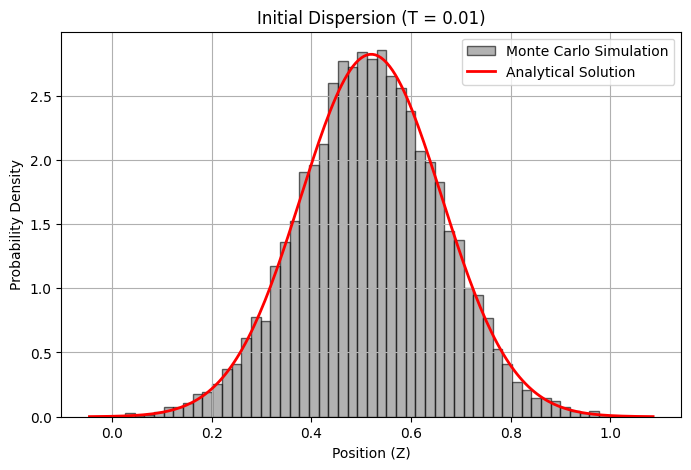

In [25]:
H, D, v = 1, 1, 2
T = 0.01
delta_t = 10**(-4)
steps = int(T / delta_t)
Z_0 = H / 2
N = 10_000

Z = np.full(N, Z_0)

for _ in range(steps):
    Z = step_vertical(Z, v, delta_t, D, H)
    
final_positions = Z

# ---------------------------------------------------------
# Analytical Solution (Infinite Domain)
# ---------------------------------------------------------
# Center of the cloud (mean)
mu = Z_0 + v * T

# Width of the cloud (standard deviation)
sigma = np.sqrt(2 * D * T)

# Generate an array of z-axis points spanning the width of the bell curve
z_vals = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 200)

# Calculate the exact y-values for the theoretical bell curve
f_z = (1 / (np.sqrt(2 * np.pi) * sigma)) * np.exp(-0.5 * ((z_vals - mu) / sigma)**2)

# ---------------------------------------------------------
# Plotting
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))

# 1. Histogram of the simulated cloud
plt.hist(final_positions, bins=50, density=True, color='gray', edgecolor='black', alpha=0.6, label='Monte Carlo Simulation')

# 2. Analytical solution curve
plt.plot(z_vals, f_z, color='red', linewidth=2, label='Analytical Solution')

plt.title("Initial Dispersion (T = 0.01)")
plt.xlabel("Position (Z)")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(True)
plt.show()

## Question 2

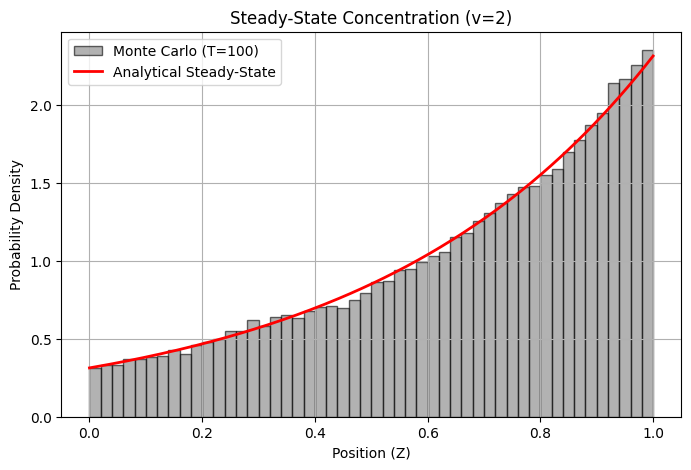

In [29]:
import numpy as np
import matplotlib.pyplot as plt

H, D, v = 1, 1, 2
z_vals = np.linspace(0, H, 200)

C_z = (v * np.exp((v / D) * z_vals)) / (D * (np.exp((v / D) * H) - 1))

# compute Z from q1a
Z_0 = H / 2
T = 100
delta_t = 10**(-3)
steps = int(T / delta_t)

Z_traj = np.zeros(steps + 1)
Z_traj[0] = Z_0

for i in range(steps):
    Z_traj[i+1] = step_vertical(Z_traj[i], v, delta_t, D, H)
    
# get Z vals from Q1a
Z = np.zeros(steps + 1)
Z[0] = H / 2

for i in range(steps):
    Z[i+1] = step_vertical(Z[i], v, delta_t, D, H)

plt.figure(figsize=(8, 5))
plt.hist(Z, bins=50, density=True, color='gray', edgecolor='black', alpha=0.6, label='Monte Carlo (T=100)')
plt.plot(z_vals, C_z, color='red', linewidth=2, label='Analytical Steady-State')

plt.title("Steady-State Concentration (v=2)")
plt.xlabel("Position (Z)")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(True)
plt.show()

## Question 3

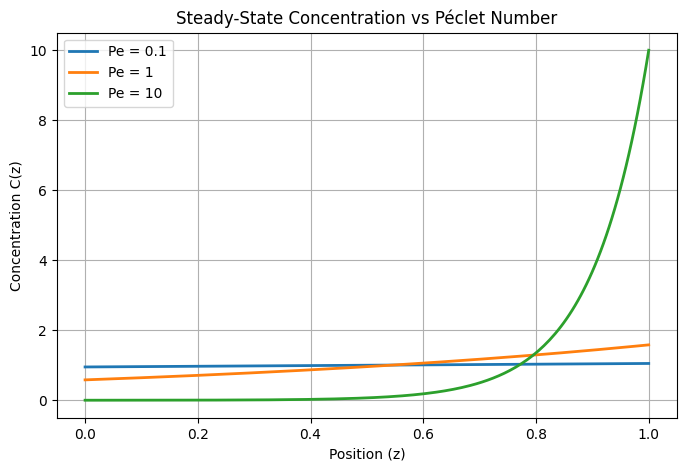

In [20]:
import numpy as np
import matplotlib.pyplot as plt

H = 1
z_vals = np.linspace(0, H, 200)
Pe_values = [0.1, 1, 10]

plt.figure(figsize=(8, 5))
for Pe in Pe_values:
    C_z = (Pe / H) * np.exp(Pe * (z_vals / H)) / (np.exp(Pe) - 1)
    plt.plot(z_vals, C_z, label=f'Pe = {Pe}', linewidth=2)

plt.title("Steady-State Concentration vs Péclet Number")
plt.xlabel("Position (z)")
plt.ylabel("Concentration C(z)")
plt.legend()
plt.grid(True)
plt.show()

## Question 4

In [ ]:
def step_horizontal(X, Z, delta_t):
    u_Z = np.log(1 + 3 * Z)
    
    X_next = X + u_Z * delta_t
    
    return X_next

H, D = 1, 1
N = 1000
X_0 = 0
Z_0 = H / 2
T = 1_000
delta_t = 10**(-3)
steps = int(T / delta_t)

X = np.zeros(N)
Z = np.full(N, Z_0)

v = 2
for _ in range(steps):
    X = step_horizontal(X, Z, delta_t)
    Z = step_vertical(Z, v, delta_t, D, H)
    
X_v2 = X

X = np.zeros(N)
Z = np.full(N, Z_0)

v = -2
for _ in range(steps):
    X = step_horizontal(X, Z, delta_t)
    Z = step_vertical(Z, v, delta_t, D, H)
    
X_vneg2 = X

print(f"Results for v=2  | Mean: {np.mean(X_v2):.2f}, Variance: {np.var(X_v2):.2f}")
print(f"Results for v=-2 | Mean: {np.mean(X_vneg2):.2f}, Variance: {np.var(X_vneg2):.2f}")

plt.figure(figsize=(9, 5))
plt.hist(X_v2, bins=30, alpha=0.6, label=f'v=2 (Var: {np.var(X_v2):.2f})', color='blue')
plt.hist(X_vneg2, bins=30, alpha=0.6, label=f'v=-2 (Var: {np.var(X_vneg2):.2f})', color='red')

plt.title("Horizontal Position at t=10 (1000 particles)")
plt.xlabel("Horizontal Position (X)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()